# <u>**Laboratório 6 – Depth Map Mapa de Profundidade**</u>

**<u>Integrantes</u>**

- Gabriel Intackli Pinto - 11201921426

- Lucas Medeiros da Silva - 11202130277

- Samira Haddad - 11201812350

**Data de Realização dos Experimentos**:

15/07/2026

**Data de Publicação do Relatório**

20/07/2026

## <u>Introdução</u>

A informação tridimensional gerada por duas câmeras pode ser obtida para a reconstrução da cena atravês da configuração conhecida como câmera estéreo a qual permite a recuperação da infomação de profundidade. Essa profundidade é fundamental para sistemas de visão computacional. Para mostrar como funciona, durante esse trabalho será apresentado os consitos teóricos e os procedimentos envolvidos para a obtenção do mapa de profundidade. Para isso foi utilizado os fundamentos da geometria epipolar, os parâmetros que descrevem uma câmera e um par de câmeras estéreo, o processo de retificação de imagens e a construção do mapa de disparidade através do algoritmo de Block Matching, culminando na conversão desse mapa em medidas reais de distância. Já na parte prática será utilizada uma câmera estereoscópica que foi contruida para outro experimento sobre a qual serão executados os procedimentos de calibração, retificação, sintonia dos parâmetros de disparidade e, por fim, a medição prática da distância de objetos reais. Os valores obtidos pelo código será comparado com a valor medido real e com isso será analisado quantitativamente o erro e a influência dos parâmetros no sistema.
Para isso o experimento será realizado atravês do seguinte modelo:


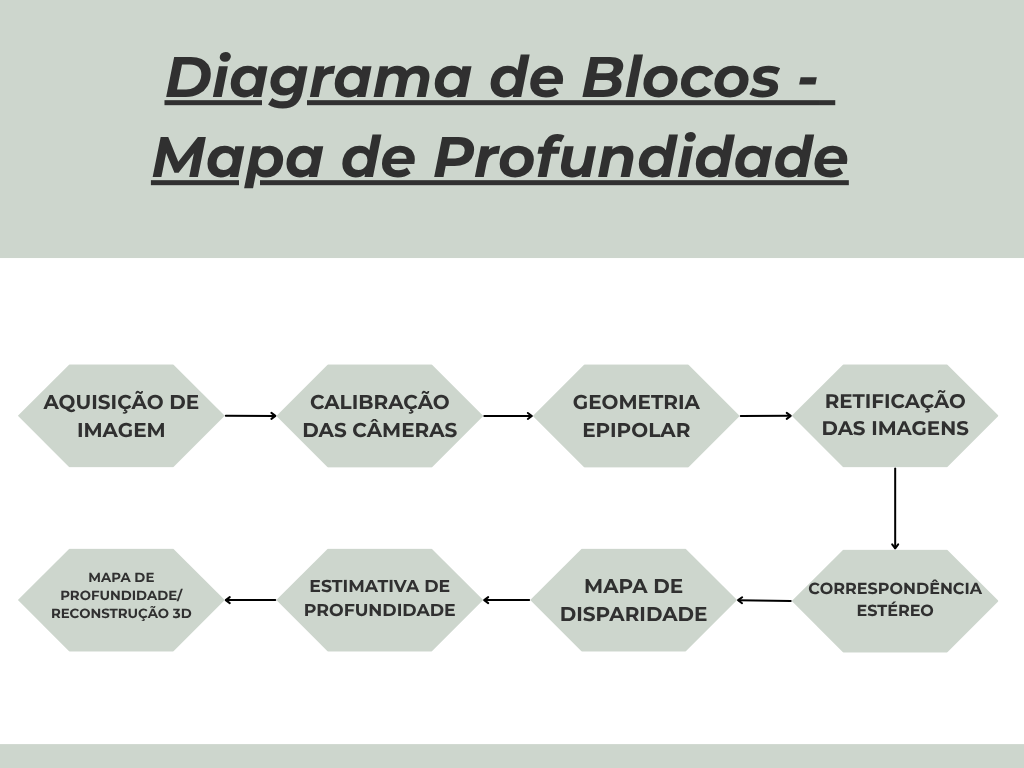

## <u>Fundamentação Teórica</u>

A visão estereoscópica computacional é uma técnica que estima a estrutura tridimensional de uma cena a partir de duas ou mais imagens, reconstruindo profundidades por meio da correspondência entre pixels observados em diferentes pontos de vista (SZELISKI, 2022). Em sistemas com duas câmeras, esse processo explora o mesmo princípio perceptivo pelo qual diferenças entre as imagens vistas por cada olho fornecem informação de profundidade (SZELISKI, 2022).

Na visão estéreo, a relação geométrica entre as duas imagens é descrita pela geometria epipolar, determinada pela pose relativa e pela calibração das câmeras (SZELISKI, 2022). Uma vez conhecida essa geometria, o ponto correspondente a um pixel de uma imagem deve estar sobre a linha epipolar da outra imagem, o que restringe o problema de correspondência e reduz a complexidade da busca (SZELISKI, 2022; SADEKAR, 2020).

Para tornar essa busca mais eficiente, aplica-se a retificação estéreo, que transforma as imagens de modo que as linhas epipolares se tornem paralelas e horizontais, colocando os pontos correspondentes em correspondência vertical (SZELISKI, 2022). Após essa etapa, a correspondência pode ser realizada independentemente ao longo das linhas horizontais, o que simplifica o processamento e viabiliza algoritmos práticos de estimação de disparidade (SZELISKI, 2022).

Com as imagens retificadas, pode-se aplicar um método de correspondência estéreo densa, como o Block Matching. Nesse tipo de abordagem, a correspondência é estimada comparando janelas de pixels ao longo da mesma linha epipolar horizontal, buscando a melhor associação entre blocos nas imagens esquerda e direita (SADEKAR, 2021).

A diferença entre as posições horizontais de um mesmo ponto nas duas imagens é chamada de disparidade. Se um ponto aparece na coordenada $x$ na imagem esquerda e em $x'$ na imagem direita, sua disparidade pode ser expressa, de forma elementar, por $d = x - x'$. O conjunto dessas disparidades para os pixels da cena forma o mapa de disparidade, que representa como os deslocamentos variam ao longo da imagem e constitui a base para a recuperação da profundidade (OPENCV, 2025).

A profundidade pode então ser obtida por triangulação, explorando a relação inversa entre profundidade ($Z$) e disparidade ($d$) em uma geometria estéreo retificada (SZELISKI, 2022). Assim, objetos mais próximos produzem maiores disparidades, enquanto objetos mais distantes produzem menores disparidades (SZELISKI, 2022). Considerando a distância focal da câmera ($f$), medida em pixels, e a linha de base ($B$), correspondente à distância entre os centros ópticos das câmeras, a profundidade é dada por $Z = \frac{B \cdot f}{d}$ (SZELISKI, 2022).

No contexto deste laboratório, essa fundamentação sustenta as etapas práticas de calibração estéreo, geração do mapa de disparidade, conversão para mapa de profundidade e realização de medidas de distância, incluindo a construção do gráfico profundidade versus disparidade e a análise do erro experimental.

## <u>Procedimentos Experimentais</u>



Procedimentos Experimentais
A metodologia deste laboratório foi estruturada em etapas sequenciais voltadas à calibração do sistema, estimação de disparidade e reconstrução de profundidade. Contudo, devido a limitações de acoplamento do hardware e ruídos na captura dinâmica com a câmera estereoscópica, o escopo original sofreu adaptações práticas, conforme detalhado a seguir:

1. Calibração da Câmera Estéreo
O procedimento iniciou-se com a calibração do par estereoscópico por meio da execução do script calibrate_abc.py. Esse processo permitiu estimar as matrizes de parâmetros intrínsecos e extrínsecos do arranjo de câmeras, cujos resultados foram estruturados e salvos no arquivo de configuração params_py.xml para subsidiar os cálculos posteriores de retificação.

In [ ]:
import cv2
import os

# ==========================================
# CONFIGURAÇÕES DA EQUIPE
# ==========================================
MAX_IMAGENS = 15

output_path = "data/"
os.makedirs(output_path + 'stereoL', exist_ok=True)
os.makedirs(output_path + 'stereoR', exist_ok=True)

# IDs das câmeras
CamL_id = 1
CamR_id = 0

print(f"Tentando conectar nas câmeras {CamL_id} e {CamR_id}...")
CamL = cv2.VideoCapture(CamL_id)
CamR = cv2.VideoCapture(CamR_id)

# Forçando resolução baixa para não travar a porta USB
CamL.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
CamL.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
CamR.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
CamR.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not CamL.isOpened() or not CamR.isOpened():
    print("ERRO: Uma ou ambas as câmeras não abriram. Mude os IDs (0, 1, 2...).")
    exit(-1)

print("\n=== INSTRUÇÕES ===")
print("1. Posicione o tabuleiro de xadrez para que apareça NAS DUAS câmeras.")
print("2. Pressione a tecla 'S' (na janela do vídeo) para SALVAR o par de fotos.")
print("3. Pressione a tecla 'ESC' para sair.")
print("==================\n")

count = 0

while True:
    retR, frameR = CamR.read()
    retL, frameL = CamL.read()

    if not retR or not retL:
        print("Erro ao ler o frame das câmeras. Verifique os cabos USB.")
        break

    imgL_vis = frameL.copy()
    imgR_vis = frameR.copy()

    cv2.putText(imgL_vis, f"Fotos salvas: {count}/{MAX_IMAGENS}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(imgL_vis, "Aperte 'S' para salvar", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    # Mostra os vídeos
    cv2.imshow('Camera ESQUERDA (L)', imgL_vis)
    cv2.imshow('Camera DIREITA (R)', imgR_vis)

    # Aguarda a tecla do usuário
    key = cv2.waitKey(1) & 0xFF

    # Se apertar 'S' (ou 's'), salva a foto
    if key == ord('s') or key == ord('S'):
        count += 1
        nome_img_R = f"{output_path}stereoR/captura_R_{count}.png"
        nome_img_L = f"{output_path}stereoL/captura_L_{count}.png"

        cv2.imwrite(nome_img_R, frameR)
        cv2.imwrite(nome_img_L, frameL)

        print(f"[{count}/{MAX_IMAGENS}] Foto salva com sucesso!")

        cv2.rectangle(imgL_vis, (0,0), (640,480), (0, 255, 0), 10)
        cv2.rectangle(imgR_vis, (0,0), (640,480), (0, 255, 0), 10)
        cv2.imshow('Camera ESQUERDA (L)', imgL_vis)
        cv2.imshow('Camera DIREITA (R)', imgR_vis)
        cv2.waitKey(200) # Pausa rápida

    # Encerra se atingir o limite
    if count >= MAX_IMAGENS:
        print(f"\nPerfeito! {MAX_IMAGENS} pares de fotos capturados.")
        break

    # Se apertar ESC, sai
    if key == 27:
        print("\nCaptura encerrada pelo usuário.")
        break

CamL.release()
CamR.release()
cv2.destroyAllWindows()

In [ ]:
import numpy as np
import cv2
from tqdm import tqdm
import os

# ==========================================
# CONFIGURAÇÕES
# ==========================================
CHECKERBOARD = (6, 8)
MAX_IMAGENS = 15

# Set the path to the images captured by the left and right cameras
pathL = "data/stereoL/"
pathR = "data/stereoR/"

print("Extracting image coordinates of respective 3D pattern ....\n")

# Termination criteria for refining the detected corners
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Cria a malha de pontos 3D baseada no tamanho do tabuleiro
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

img_ptsL = []
img_ptsR = []
obj_pts = []

for i in tqdm(range(1, MAX_IMAGENS + 1)):
    imgL_path = f"{pathL}captura_L_{i}.png"
    imgR_path = f"{pathR}captura_R_{i}.png"

    # Pula se o arquivo não existir
    if not os.path.exists(imgL_path) or not os.path.exists(imgR_path):
        continue

    imgL = cv2.imread(imgL_path)
    imgR = cv2.imread(imgR_path)
    imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    outputL = imgL.copy()
    outputR = imgR.copy()

    retR, cornersR = cv2.findChessboardCorners(outputR, CHECKERBOARD, None)
    retL, cornersL = cv2.findChessboardCorners(outputL, CHECKERBOARD, None)

    if retR and retL:
        obj_pts.append(objp)
        cv2.cornerSubPix(imgR_gray, cornersR, (11,11), (-1,-1), criteria)
        cv2.cornerSubPix(imgL_gray, cornersL, (11,11), (-1,-1), criteria)

        img_ptsL.append(cornersL)
        img_ptsR.append(cornersR)


print("\nCalculating left camera parameters ... ")
retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(obj_pts, img_ptsL, imgL_gray.shape[::-1], None, None)
hL, wL = imgL_gray.shape[:2]
new_mtxL, roiL = cv2.getOptimalNewCameraMatrix(mtxL, distL, (wL,hL), 1, (wL,hL))

print("Calculating right camera parameters ... ")
retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(obj_pts, img_ptsR, imgR_gray.shape[::-1], None, None)
hR, wR = imgR_gray.shape[:2]
new_mtxR, roiR = cv2.getOptimalNewCameraMatrix(mtxR, distR, (wR,hR), 1, (wR,hR))


print("Stereo calibration .....")
flags = 0
flags |= cv2.CALIB_FIX_INTRINSIC

criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

retS, new_mtxL, distL, new_mtxR, distR, Rot, Trns, Emat, Fmat = cv2.stereoCalibrate(
    obj_pts, img_ptsL, img_ptsR, new_mtxL, distL, new_mtxR, distR,
    imgL_gray.shape[::-1], criteria_stereo, flags)

rectify_scale = 1
rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR = cv2.stereoRectify(
    new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, rectify_scale, (0,0))

Left_Stereo_Map = cv2.initUndistortRectifyMap(new_mtxL, distL, rect_l, proj_mat_l, imgL_gray.shape[::-1], cv2.CV_16SC2)
Right_Stereo_Map = cv2.initUndistortRectifyMap(new_mtxR, distR, rect_r, proj_mat_r, imgR_gray.shape[::-1], cv2.CV_16SC2)

print("\n--- RESULTADOS PARA O RELATÓRIO ---")
print("Matriz de Rotação (Rot):\n", Rot)
print("\nVetor de Translação (Trns):\n", Trns)
print("\nMatriz Essencial (Emat):\n", Emat)
print("\nMatriz Fundamental (Fmat):\n", Fmat)
print("-----------------------------------\n")

print("Saving parameters ......")
xml_path = f"data/params_py.xml"
cv_file = cv2.FileStorage(xml_path, cv2.FILE_STORAGE_WRITE)
cv_file.write("Left_Stereo_Map_x", Left_Stereo_Map[0])
cv_file.write("Left_Stereo_Map_y", Left_Stereo_Map[1])
cv_file.write("Right_Stereo_Map_x", Right_Stereo_Map[0])
cv_file.write("Right_Stereo_Map_y", Right_Stereo_Map[1])
cv_file.release()
print(f"Salvo com sucesso em {xml_path}")

2. Correspondência Estéreo via Block Matching
Com a geometria retificada, executou-se o algoritmo de Block Matching da biblioteca OpenCV para determinar a correspondência densa de pixels ao longo das linhas epipolares horizontais. Os parâmetros de ajuste e limiares adotados para otimizar o casamento de blocos nessa etapa foram armazenados no arquivo depth_estimation_params_py.xml.

In [ ]:
import numpy as np
import cv2

# --- CONFIGURAÇÃO DOS CAMINHOS ---
CAMINHO_IMG_ESQ = "data/im0.png"
CAMINHO_IMG_DIR = "data/im1.png"

# Lendo as imagens estáticas e redimensionando para o padrão
imgL_orig = cv2.imread(CAMINHO_IMG_ESQ)
imgR_orig = cv2.imread(CAMINHO_IMG_DIR)

if imgL_orig is None or imgR_orig is None:
    print("Erro: Imagens não encontradas. Verifique o caminho.")
    exit()

imgL = cv2.resize(imgL_orig, (640, 480))
imgR = cv2.resize(imgR_orig, (640, 480))

imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

def nothing(x):
    pass

cv2.namedWindow('Controles', cv2.WINDOW_NORMAL)
cv2.resizeWindow('Controles', 600, 600)
cv2.namedWindow('Mapa de Disparidade', cv2.WINDOW_NORMAL)
cv2.resizeWindow('Mapa de Disparidade', 640, 480)

cv2.createTrackbar('numDisparities','Controles',3,17,nothing)
cv2.createTrackbar('blockSize','Controles',5,50,nothing)
cv2.createTrackbar('preFilterType','Controles',1,1,nothing)
cv2.createTrackbar('preFilterSize','Controles',2,25,nothing)
cv2.createTrackbar('preFilterCap','Controles',31,62,nothing)
cv2.createTrackbar('textureThreshold','Controles',10,100,nothing)
cv2.createTrackbar('uniquenessRatio','Controles',15,100,nothing)
cv2.createTrackbar('speckleRange','Controles',2,100,nothing)
cv2.createTrackbar('speckleWindowSize','Controles',25,100,nothing)
cv2.createTrackbar('disp12MaxDiff','Controles',5,25,nothing)
cv2.createTrackbar('minDisparity','Controles',0,25,nothing)

stereo = cv2.StereoBM_create()

while True:
    # Lendo os valores da janela de 'Controles'
    raw_numDisp = cv2.getTrackbarPos('numDisparities','Controles')
    numDisparities = max(1, raw_numDisp) * 16
    blockSize = cv2.getTrackbarPos('blockSize','Controles')*2 + 5
    preFilterType = cv2.getTrackbarPos('preFilterType','Controles')
    preFilterSize = cv2.getTrackbarPos('preFilterSize','Controles')*2 + 5
    preFilterCap = max(1, cv2.getTrackbarPos('preFilterCap','Controles'))
    textureThreshold = cv2.getTrackbarPos('textureThreshold','Controles')
    uniquenessRatio = cv2.getTrackbarPos('uniquenessRatio','Controles')
    speckleRange = cv2.getTrackbarPos('speckleRange','Controles')
    speckleWindowSize = cv2.getTrackbarPos('speckleWindowSize','Controles')*2
    disp12MaxDiff = cv2.getTrackbarPos('disp12MaxDiff','Controles')
    minDisparity = cv2.getTrackbarPos('minDisparity','Controles')

    stereo.setNumDisparities(numDisparities)
    stereo.setBlockSize(blockSize)
    stereo.setPreFilterType(preFilterType)
    stereo.setPreFilterSize(preFilterSize)
    stereo.setPreFilterCap(preFilterCap)
    stereo.setTextureThreshold(textureThreshold)
    stereo.setUniquenessRatio(uniquenessRatio)
    stereo.setSpeckleRange(speckleRange)
    stereo.setSpeckleWindowSize(speckleWindowSize)
    stereo.setDisp12MaxDiff(disp12MaxDiff)
    stereo.setMinDisparity(minDisparity)

    # Computando a disparidade (sem o remap, pois a imagem de teste é perfeita)
    disparity = stereo.compute(imgL_gray, imgR_gray)
    disparity_float = disparity.astype(np.float32)
    disparity_norm = (disparity_float/16.0 - minDisparity) / numDisparities

    # Prevenção contra artefatos brancos
    disparity_norm = np.clip(disparity_norm, 0, 1)

    disp_vis = (disparity_norm * 255).astype(np.uint8)
    disp_color = cv2.cvtColor(disp_vis, cv2.COLOR_GRAY2BGR)

    cv2.putText(disp_color, "Aperte ESC para salvar os parametros", (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2.imshow("Mapa de Disparidade", disp_color)

    if cv2.waitKey(50) == 27:
        break

print("Salvando parâmetros de estimativa de profundidade...")
cv_file = cv2.FileStorage("data/depth_estimation_params_py.xml", cv2.FILE_STORAGE_WRITE)
cv_file.write("numDisparities", numDisparities)
cv_file.write("blockSize", blockSize)
cv_file.write("preFilterType", preFilterType)
cv_file.write("preFilterSize", preFilterSize)
cv_file.write("preFilterCap", preFilterCap)
cv_file.write("textureThreshold", textureThreshold)
cv_file.write("uniquenessRatio", uniquenessRatio)
cv_file.write("speckleRange", speckleRange)
cv_file.write("speckleWindowSize", speckleWindowSize)
cv_file.write("disp12MaxDiff", disp12MaxDiff)
cv_file.write("minDisparity", minDisparity)
cv_file.write("M", 39.075) # Valor genérico inicial
cv_file.release()

cv2.destroyAllWindows()

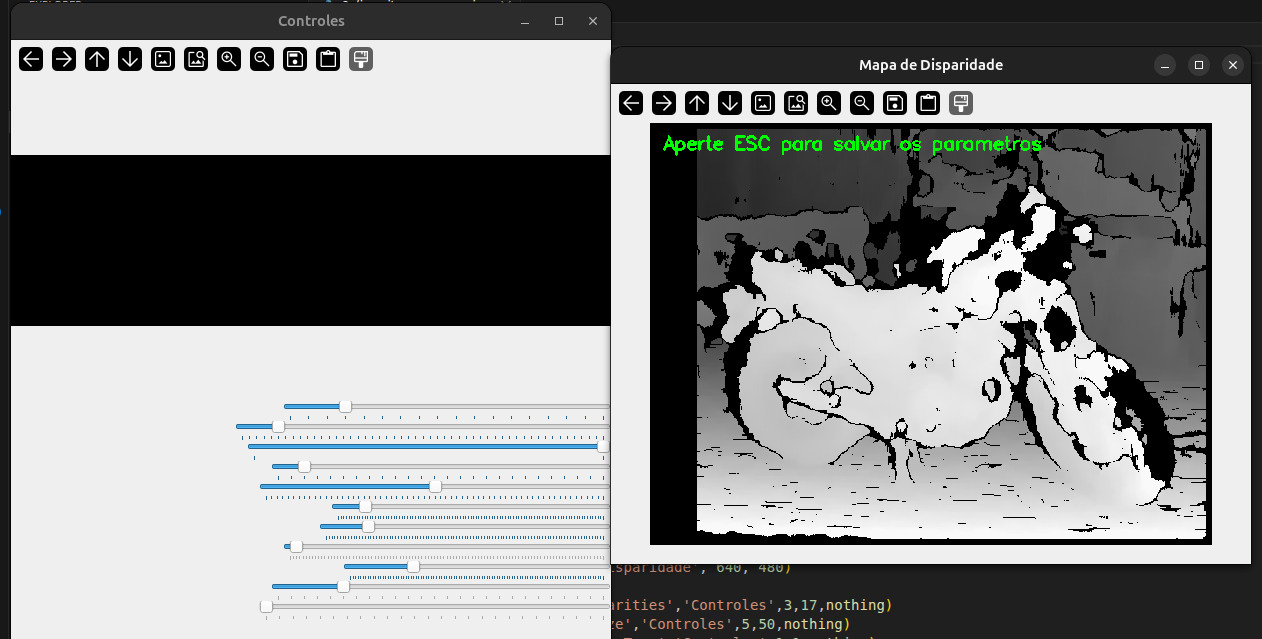

3. Geração do Mapa de Profundidade e Adaptação para Imagem Estática
A conversão da matriz de disparidade calculada em um mapa de profundidade tridimensional foi realizada através do script disparity2depth_calib.py, fundamentando-se na relação de triangulação e na construção do gráfico descritivo "Profundidade versus Disparidade".

    Nota de desvio instrumental: Inicialmente, buscou-se gerar esse mapeamento em tempo real utilizando o fluxo de vídeo direto de uma câmera estereocópica física. Todavia, os dados brutos apresentaram elevado nível de ruído e instabilidade, impedindo uma visualização coerente. Para contornar essa limitação técnica e validar o funcionamento dos scripts, utilizou-se um par de imagens estáticas para o processamento. O mapa de profundidade obtido a partir dessa abordagem controlada pode ser observado na Figura 1.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DOS CAMINHOS ---
CAMINHO_IMG_ESQ = "data/im0.png"
CAMINHO_IMG_DIR = "data/im1.png"

Value_pairs = []
disparity = None

# Lendo os parâmetros salvos no código anterior
cv_file = cv2.FileStorage("data/depth_estimation_params_py.xml", cv2.FILE_STORAGE_READ)
numDisparities = int(cv_file.getNode("numDisparities").real())
blockSize = int(cv_file.getNode("blockSize").real())
preFilterType = int(cv_file.getNode("preFilterType").real())
preFilterSize = int(cv_file.getNode("preFilterSize").real())
preFilterCap = int(cv_file.getNode("preFilterCap").real())
textureThreshold = int(cv_file.getNode("textureThreshold").real())
uniquenessRatio = int(cv_file.getNode("uniquenessRatio").real())
speckleRange = int(cv_file.getNode("speckleRange").real())
speckleWindowSize = int(cv_file.getNode("speckleWindowSize").real())
disp12MaxDiff = int(cv_file.getNode("disp12MaxDiff").real())
minDisparity = int(cv_file.getNode("minDisparity").real())
cv_file.release()

def mouse_click(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        disp_val = disparity[y,x]
        if disp_val > 0:
            print(f"\n[CLIQUE DETECTADO] Disparidade no pixel: {disp_val}")
            try:
                Z_lido = float(input("Digite a distância real medida (em cm): "))
                Value_pairs.append([Z_lido, disp_val])
                print("-> Registrado! Clique em outro ponto ou aperte ESC na imagem para calcular o M.")
            except ValueError:
                print("Valor inválido. Digite apenas números.")
        else:
            print("\nVocê clicou em uma área sem disparidade válida. Tente novamente.")

cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 600, 600)
cv2.namedWindow('left image', cv2.WINDOW_NORMAL)
cv2.resizeWindow('left image', 600, 600)
cv2.setMouseCallback('disp', mouse_click)

stereo = cv2.StereoBM_create()

imgL_orig = cv2.imread(CAMINHO_IMG_ESQ)
imgR_orig = cv2.imread(CAMINHO_IMG_DIR)

imgL = cv2.resize(imgL_orig, (640, 480))
imgR = cv2.resize(imgR_orig, (640, 480))

imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

stereo.setNumDisparities(numDisparities)
stereo.setBlockSize(blockSize)
stereo.setPreFilterType(preFilterType)
stereo.setPreFilterSize(preFilterSize)
stereo.setPreFilterCap(preFilterCap)
stereo.setTextureThreshold(textureThreshold)
stereo.setUniquenessRatio(uniquenessRatio)
stereo.setSpeckleRange(speckleRange)
stereo.setSpeckleWindowSize(speckleWindowSize)
stereo.setDisp12MaxDiff(disp12MaxDiff)
stereo.setMinDisparity(minDisparity)

disparity_raw = stereo.compute(imgL_gray, imgR_gray)
disparity_float = disparity_raw.astype(np.float32)
disparity = (disparity_float/16.0 - minDisparity)/numDisparities

while True:
    cv2.imshow("disp", disparity)
    cv2.imshow("left image", imgL)

    if cv2.waitKey(50) == 27:
        if len(Value_pairs) > 0:
            break
        else:
            print("Aviso: Você precisa registrar pelo menos 1 ponto antes de sair!")

# Matemática e correção de formato da matriz para o OpenCV C++
value_pairs = np.array(Value_pairs)
z = value_pairs[:,0]
disp = value_pairs[:,1]
disp_inv = 1/disp

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.plot(disp, z, 'o-')
ax1.set(xlabel='Normalized disparity value', ylabel='Depth from camera (cm)', title='Depth vs Disparity')
ax1.grid()
ax2.plot(disp_inv, z, 'o-')
ax2.set(xlabel='Inverse disparity value (1/disp) ', ylabel='Depth from camera (cm)', title='Depth vs Inverse Disparity')
ax2.grid()
plt.show()

coeff = np.vstack([disp_inv, np.ones(len(disp_inv))]).T
coeff = np.float32(coeff)
z_matrix = np.float32(z).reshape(-1, 1)

ret, sol = cv2.solve(coeff, z_matrix, flags=cv2.DECOMP_QR)
M = sol[0,0]
print(f"Valor final de M = {M}")

cv_file = cv2.FileStorage("data/depth_estimation_params_py.xml", cv2.FILE_STORAGE_WRITE)
cv_file.write("numDisparities", numDisparities)
cv_file.write("blockSize", blockSize)
cv_file.write("preFilterType", preFilterType)
cv_file.write("preFilterSize", preFilterSize)
cv_file.write("preFilterCap", preFilterCap)
cv_file.write("textureThreshold", textureThreshold)
cv_file.write("uniquenessRatio", uniquenessRatio)
cv_file.write("speckleRange", speckleRange)
cv_file.write("speckleWindowSize", speckleWindowSize)
cv_file.write("disp12MaxDiff", disp12MaxDiff)
cv_file.write("minDisparity", minDisparity)
cv_file.write("M", M)
cv_file.release()
cv2.destroyAllWindows()

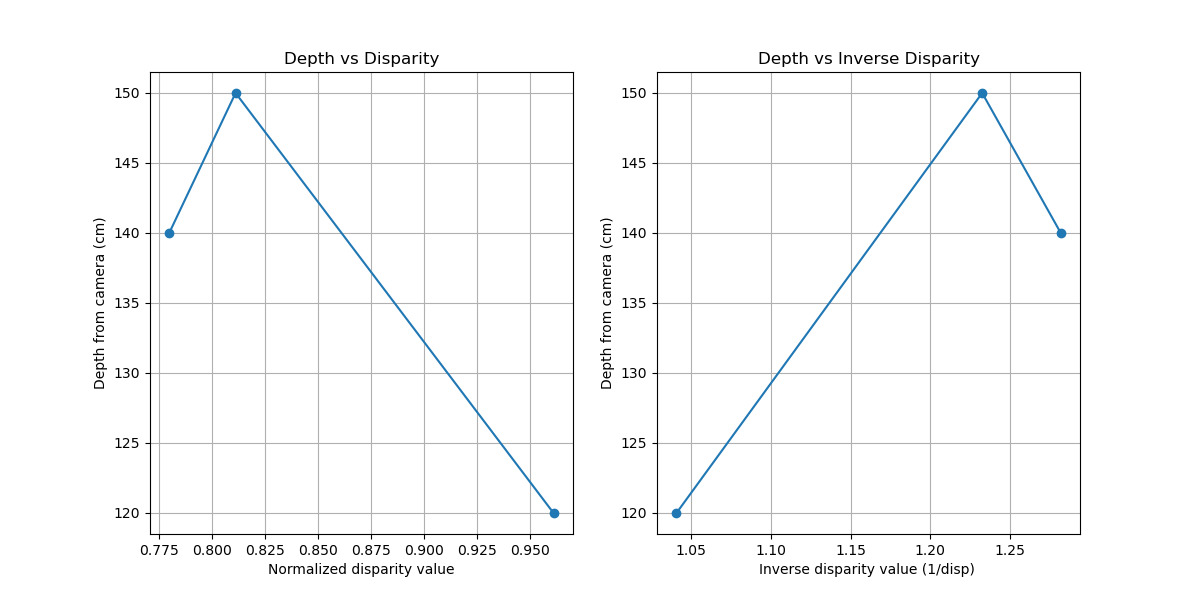

4. Restrições na Análise Quantitativa e Evitação de Obstáculos
As etapas finais do cronograma experimental (evitação de obstáculos) e a posterior consolidação de uma tabela comparativa de erros entre a distância real e a distância medida por software foram descontinuadas. Uma vez que o algoritmo não obteve a estabilidade necessária durante a execução com o fluxo dinâmico da câmera estereoscópica, tornou-se impossível extrair métricas de distância em tempo real de forma confiável, inviabilizando o cálculo e a análise estatística do erro experimental.

In [ ]:
import numpy as np
import cv2

# --- CONFIGURAÇÃO DOS CAMINHOS ---
CAMINHO_IMG_ESQ = "data/im0.png"
CAMINHO_IMG_DIR = "data/im1.png"

max_depth = 400
min_depth = 50
depth_thresh = 100.0 # Limite de proximidade do objeto

disparity = None
depth_map = None
output_canvas = None

cv_file = cv2.FileStorage("data/depth_estimation_params_py.xml", cv2.FILE_STORAGE_READ)
numDisparities = int(cv_file.getNode("numDisparities").real())
blockSize = int(cv_file.getNode("blockSize").real())
preFilterType = int(cv_file.getNode("preFilterType").real())
preFilterSize = int(cv_file.getNode("preFilterSize").real())
preFilterCap = int(cv_file.getNode("preFilterCap").real())
textureThreshold = int(cv_file.getNode("textureThreshold").real())
uniquenessRatio = int(cv_file.getNode("uniquenessRatio").real())
speckleRange = int(cv_file.getNode("speckleRange").real())
speckleWindowSize = int(cv_file.getNode("speckleWindowSize").real())
disp12MaxDiff = int(cv_file.getNode("disp12MaxDiff").real())
minDisparity = int(cv_file.getNode("minDisparity").real())
M = cv_file.getNode("M").real()
cv_file.release()

def mouse_click(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        print("Distância estimada: %.2f cm" % depth_map[y,x])

cv2.namedWindow('disp', cv2.WINDOW_NORMAL)
cv2.resizeWindow('disp', 700, 700)
cv2.namedWindow('output_canvas', cv2.WINDOW_NORMAL)
cv2.resizeWindow('output_canvas', 700, 700)
cv2.setMouseCallback('disp', mouse_click)
cv2.setMouseCallback('output_canvas', mouse_click)

stereo = cv2.StereoBM_create()

def obstacle_avoid():
    mask = cv2.inRange(depth_map, 10, depth_thresh)
    if np.sum(mask)/255.0 > 0.01*mask.shape[0]*mask.shape[1]:
        contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        cnts = sorted(contours, key=cv2.contourArea, reverse=True)
        if cv2.contourArea(cnts[0]) > 0.01*mask.shape[0]*mask.shape[1]:
            x, y, w, h = cv2.boundingRect(cnts[0])
            mask2 = np.zeros_like(mask)
            cv2.drawContours(mask2, cnts, 0, (255), -1)
            depth_mean, _ = cv2.meanStdDev(depth_map, mask=mask2)

            cv2.putText(output_canvas, "WARNING !", (x+5, y-40), 1, 2, (0,0,255), 2, 2)
            cv2.putText(output_canvas, "Object at", (x+5, y), 1, 2, (100,10,25), 2, 2)
            cv2.putText(output_canvas, "%.2f cm" % depth_mean[0][0], (x+5, y+40), 1, 2, (100,10,25), 2, 2)
    else:
        cv2.putText(output_canvas, "SAFE!", (100, 100), 1, 3, (0,255,0), 2, 3)

imgL_orig = cv2.imread(CAMINHO_IMG_ESQ)
imgR_orig = cv2.imread(CAMINHO_IMG_DIR)

imgL = cv2.resize(imgL_orig, (640, 480))
imgR = cv2.resize(imgR_orig, (640, 480))

output_canvas = imgL.copy()

imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)

stereo.setNumDisparities(numDisparities)
stereo.setBlockSize(blockSize)
stereo.setPreFilterType(preFilterType)
stereo.setPreFilterSize(preFilterSize)
stereo.setPreFilterCap(preFilterCap)
stereo.setTextureThreshold(textureThreshold)
stereo.setUniquenessRatio(uniquenessRatio)
stereo.setSpeckleRange(speckleRange)
stereo.setSpeckleWindowSize(speckleWindowSize)
stereo.setDisp12MaxDiff(disp12MaxDiff)
stereo.setMinDisparity(minDisparity)

disparity_raw = stereo.compute(imgL_gray, imgR_gray)
disparity_float = disparity_raw.astype(np.float32)
disparity = (disparity_float/16.0 - minDisparity)/numDisparities

# Blindagem contra divisão por zero onde não há disparidade
depth_map = M / (disparity + 1e-6)

mask_temp = cv2.inRange(depth_map, min_depth, max_depth)
depth_map = cv2.bitwise_and(depth_map, depth_map, mask=mask_temp)

obstacle_avoid()

cv2.imshow("disp", disparity)
cv2.imshow("output_canvas", output_canvas)

print("Processamento concluído. Dê duplo-clique nas janelas para ver a distância!")
print("Aperte qualquer tecla na imagem para sair.")

# Espera infinita até você pressionar alguma tecla para fechar
cv2.waitKey(0)
cv2.destroyAllWindows()

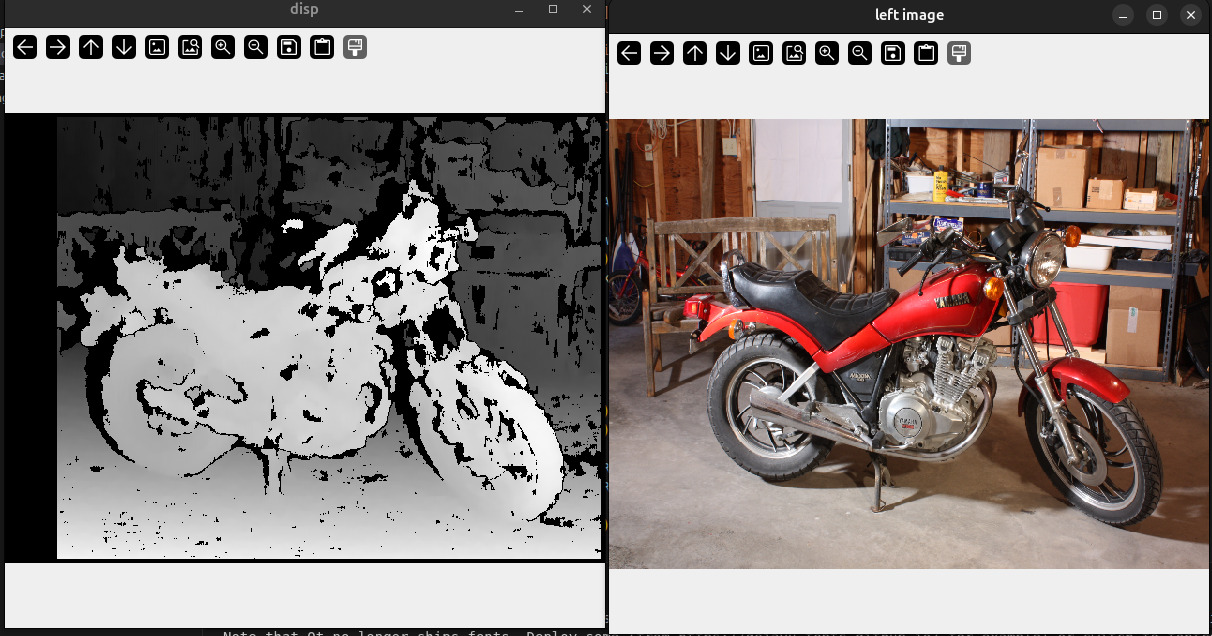

## <u>Análise e Discussão dos Estudos</u>


### Qualidade do mapa de disparidade:
A Figura 2 apresenta o mapa de disparidade obtido a partir do par de imagens estéreo estáticas de uma motocicleta, ao lado da imagem original da câmera esquerda. É possível observar uma boa separação entre os planos da cena: a motocicleta, localizada em primeiro plano, aparece destacada em tons claros (indicando maior disparidade, associada a menor distância), enquanto o fundo da garagem, mais distante, aparece em tons escuros. Esse resultado indica que o algoritmo de Block Matching, após a etapa de retificação, foi capaz de identificar corretamente as correspondências entre as imagens ao longo das linhas epipolares, validando qualitativamente o pipeline de calibração e retificação implementado.

Analisando o mapa com mais detalhe, observa-se que:

- Os contornos gerais da motocicleta ficaram bem definidos, especialmente no corpo central e no assento, regiões com textura suficiente para uma correspondência confiável entre os blocos comparados;
- As rodas apresentam disparidade ligeiramente inferior à do corpo da moto, o que é coerente com o fato de estarem posicionadas um pouco mais distantes/lateralmente em relação ao plano frontal do veículo;
- Nota-se ruído e descontinuidades em pequenas regiões — sobretudo em áreas escuras, reflexivas (partes cromadas/metálicas) e em zonas de sombra —, onde o algoritmo de Block Matching tem maior dificuldade em encontrar correspondências únicas, por conta da baixa textura ou da presença de reflexos especulares;
- O fundo da cena, embora seja apresentado em tons majoritariamente uniformes (indicando disparidade baixa e consistente com maior distância), também apresenta pequenas manchas de ruído, provavelmente decorrentes de regiões de baixo contraste na parede e nas prateleiras ao fundo.

Esses resultados sugerem que os parâmetros do Block Matching (`numDisparities`, `blockSize`, `uniquenessRatio`, entre outros) foram sintonizados de forma satisfatória para esse par de imagens, produzindo um mapa denso e globalmente coerente com a estrutura da cena, ainda que ajustes finos adicionais — como o aumento do `speckleWindowSize` ou a aplicação de um filtro de pós-processamento — pudessem reduzir ainda mais o ruído remanescente nas bordas e nas regiões pouco texturizadas.

### Relação entre profundidade e disparidade
A Figura 3 apresenta as curvas de profundidade em função da disparidade normalizada e da disparidade inversa, construídas a partir de três pontos de calibração (120 cm, 140 cm e 150 cm). Diferentemente do comportamento previsto pela relação teórica *Z = f · B / d*, que estabelece uma relação inversa e monotônica entre profundidade e disparidade — e, consequentemente, uma relação aproximadamente linear entre profundidade e disparidade inversa —, os pontos obtidos experimentalmente não seguiram essa tendência: a profundidade cresceu de 140 cm para 150 cm com o aumento da disparidade normalizada, para em seguida cair para 120 cm com uma disparidade ainda maior.

Essa discrepância pode ser atribuída a alguns fatores prováveis:

- O número reduzido de pontos de calibração (apenas três), insuficiente para caracterizar de forma confiável a curva profundidade × disparidade, especialmente na presença de ruído de medição;
- Possíveis imprecisões na estimativa da disparidade nas regiões específicas onde as medições foram realizadas, o que impactaria diretamente a proporcionalidade esperada;
- O uso de uma imagem estática, que limitou o controle experimental sobre o posicionamento exato dos objetos e das distâncias reais utilizadas como referência.

Dessa forma, embora o mapa de disparidade tenha apresentado boa qualidade qualitativa (Figura 2), a etapa de conversão quantitativa para profundidade métrica não pôde ser validada de forma consistente com o modelo teórico, evidenciando a necessidade de uma calibração empírica mais robusta — com mais pontos, distribuídos em uma faixa maior e mais controlada de distâncias — para uma estimativa confiável de profundidade a partir do mapa de disparidade.

## <u>Conclusão</u>

Neste trabalho, foram estudados e aplicados os conceitos fundamentais de visão estéreo necessários para a obtenção de um mapa de profundidade, incluindo a geometria epipolar, a calibração de câmeras, a retificação de imagens e a construção do mapa de disparidade através do algoritmo de Block Matching.

Na etapa de calibração estéreo, o processo foi realizado com sucesso, obtendo-se parâmetros intrínsecos e extrínsecos coerentes com o esperado.

Durante a etapa prática, não foi possível realizar o experimento utilizando a captura em tempo real através do par de webcams. Como alternativa, o experimento foi conduzido com sucesso utilizando um par de imagens estéreo estáticas.

O processo de retificação das imagens estáticas foi realizado com sucesso, alinhando corretamente as linhas epipolares entre as duas imagens.

Quanto ao mapa de disparidade obtido a partir das imagens estáticas, a sintonia dos parâmetros do algoritmo de Block Matching também apresentou resultado satisfatório.

Na conversão do mapa de disparidade para o mapa de profundidade, a relação teórica

$$Z = \frac{f \cdot B}{d}$$

não se aproximou de forma consistente do comportamento teórico esperado, sendo necessários ajustes empíricos adicionais para validar essa relação.

Não foi possível realizar as medições reais de distância dos objetos, uma vez que o experimento foi conduzido a partir de uma imagem estática, sem a possibilidade de posicionamento físico de objetos e aferição da distância real para fins de comparação.

De forma geral, o experimento permitiu validar a compreensão teórica e a implementação do pipeline de estereoscopia, ainda que com a limitação de não ter sido possível a captura em tempo real com o hardware disponível.

## <u>Referências</u>

#### Nota a respeito do uso de IA generativa
Em consonância com a norma com a portaria 2664/2026 da Cnpq, declaramos que durante o desenvolvimento deste trabalho, foram utilizadas ferramentas de inteligência artificial generativa de forma auxiliar. O assistente ChatGPT GPT-4o e Gemini 2.5 Flash foi empregado para revisão ortográfica e gramatical e formatação de referências bibliográficas. Todo o conteúdo intelectual, a análise crítica, a interpretação dos dados e as conclusões são de autoria exclusiva dos discentes. As saídas das ferramentas de IA foram integralmente revisadas e reescritas pelo autor antes da incorporação ao texto.

<br>

OPENCV. Depth Map from Stereo Images. OpenCV 4.13.0 Documentation, 2025. Disponível em: https://docs.opencv.org/4.13.0/dd/d53/tutorial_py_depthmap.html. Acesso em: 20 jul. 2026.

SADEKAR, Kaustubh. Introduction to Epipolar Geometry and Stereo Vision. LearnOpenCV, 28 dez. 2020. Disponível em: https://learnopencv.com/introduction-to-epipolar-geometry-and-stereo-vision/. Acesso em: 20 jul. 2026.

SADEKAR, Kaustubh. Stereo Camera Depth Estimation With OpenCV (Python/C++). LearnOpenCV, 5 abr. 2021. Disponível em: https://learnopencv.com/depth-perception-using-stereo-camera-python-c/. Acesso em: 20 jul. 2026.

SZELISKI, Richard. Computer Vision: Algorithms and Applications. 2. ed. Londres: Springer, 2022. Cap. 12.